<a href="https://colab.research.google.com/github/vandanasri/TitanicEDA/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

# R1 — Dataset overview

In [3]:
df = pd.read_csv('/content/TitanicEDA/train_titanic.csv')
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
477,478,0,3,"Braund, Mr. Lewis Richard",male,29.0,1,0,3460,7.0458,NaN,S
323,324,1,2,"Caldwell, Mrs. Albert Francis (Sylvia Mae Harb...",female,22.0,1,1,248738,29.0000,NaN,S
361,362,0,2,"del Carlo, Mr. Sebastiano",male,29.0,1,0,SC/PARIS 2167,27.7208,NaN,C
411,412,0,3,"Hart, Mr. Henry",male,NaN,0,0,394140,6.8583,NaN,Q
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C
211,212,1,2,"Cameron, Miss. Clear Annie",female,35.0,0,0,F.C.C. 13528,21.0000,NaN,S
540,541,1,1,"Crosby, Miss. Harriet R",female,36.0,0,2,WE/P 5735,71.0000,B22,S
811,812,0,3,"Lester, Mr. James",male,39.0,0,0,A/4 48871,24.1500,NaN,S
307,308,1,1,"Penasco y Castellana, Mrs. Victor de Satode (M...",female,17.0,1,0,PC 17758,108.9000,C65,C


### R1-1 Shape, column names, dtypes.

In [4]:
# check rows and columns
df.shape

(891, 12)

In [5]:
# All the columns present in dataset
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
# Get dtypes of all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


###R1-2  A sentence stating what one row represents uniqueness is PassengerId

In [ ]:
# PassengerId id fully unique
df["PassengerId"].is_unique

True

In [ ]:
# Get all column names and all columns are labelled and unique.
df.columns.value_counts()

,count
PassengerId,1
Survived,1
Pclass,1
Name,1
Sex,1
Age,1
SibSp,1
Parch,1
Ticket,1
Fare,1


In [ ]:
# only numerical columns
df.select_dtypes(include=np.number).columns.tolist()

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [ ]:
# Get only the categorical columns
df.select_dtypes(include='object').columns.tolist()

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [ ]:
# Count unique values in each categorical column
df.select_dtypes(include='object').nunique()

,0
Name,891
Sex,2
Ticket,681
Cabin,147
Embarked,3


In [ ]:
# Count unique values in each numerical column
df.select_dtypes(include=np.number).nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Age,88
SibSp,7
Parch,7
Fare,248


# R2 — Data quality audit

### R2-1 Missing Values


In [ ]:
# Total missing values dataset
df.isna().sum().sum()

np.int64(866)

In [ ]:
# Missing values per columns
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Calculate percentage of missing values for each column
missing_percent = (df.isna().mean() * 100).round(2)

# Keep only columns that actually have missing values
missing_percent = missing_percent[missing_percent > 0]

# Split into two separate variables
column_names = missing_percent.index.tolist()
percentages = missing_percent.values.tolist()
# Display results
print("Columns with missing values:", column_names)
print("Missing percentages:", percentages)

Columns with missing values: ['Age', 'Cabin', 'Embarked']
Missing percentages: [19.87, 77.1, 0.22]


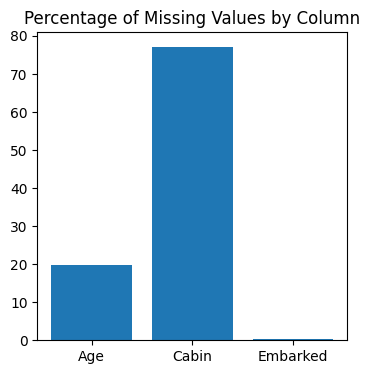

In [ ]:
# Below garph which clearly shows missing values
plt.figure(figsize=(4, 4))
plt.bar(column_names,percentages)
plt.title('Percentage of Missing Values by Column')
plt.show()

- There are total 866 missing values in Titanic dataset.
- There are only 3 columns [Cabin, Age, Embarked] which has missing values.
- Cabin has the most 687 missing data with almost 77.1% of missing data.
- Age has 177 missing data with 19.87% in entire 891 rows.
- Embarked has least 2 missing values with 0.22%.
- By above graph it is clearly visible the cabin has the heighest missing value, the cabin and age can effect future prediction.

###R2-2 Duplicated rows and duplicated ids

In [7]:
#Checking for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Fully duplicated rows: {duplicate_rows}")

#Checking for duplicate ids
duplicate_ids = df["PassengerId"].duplicated().sum()
print(f"Duplicated PassengerId values: {duplicate_ids}")

Fully duplicated rows: 0
Duplicated PassengerId values: 0


No duplicate rows and no duplicate ids — this dataset does not need de-duplication.

### R2-3 — Impossible values (negative ages, future dates, percentages above 100, etc.)